# Задача 1. Побудова дерева рішень для прогнозу цін на житло (Housing Prices)
- Мета: Реалізувати модель дерева рішень на основі набору housing.csv.
- Завдання:
1.	Завантажте набір даних (можна взяти з Kaggle Housing Prices або sklearn.datasets.fetch_california_housing).
2.	Проведіть попередню обробку (заповнення пропусків, кодування категорій).
3.	Побудуйте дерево рішень для передбачення ціни.
4.	Виведіть глибину дерева, важливість ознак.
5.	Візуалізуйте дерево та оцініть якість на тестовій вибірці (RMSE, R²).

Завантажуємо дані з файлу housing.csv...
Файл housing.csv успішно завантажено.
Завантажено 546 записів даних з 13 колонками.
------------------------------------------------------- 

Перші 5 рядків даних:
   rownames  price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0         1  42000     5850         3        1        2      yes      no   
1         2  38500     4000         2        1        1      yes      no   
2         3  49500     3060         3        1        1      yes      no   
3         4  60500     6650         3        1        2      yes     yes   
4         5  61000     6360         2        1        1      yes      no   

  fullbase gashw airco  garagepl prefarea  
0      yes    no    no         1       no  
1       no    no    no         0       no  
2       no    no    no         0       no  
3       no    no    no         0       no  
4       no    no    no         0       no  
------------------------------------------------------- 

Стовпець 'rownam

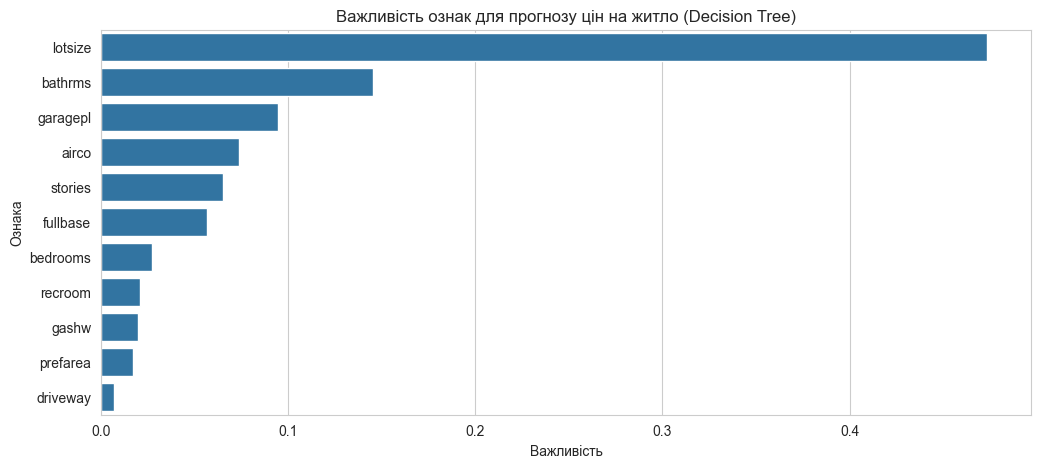


Оцінюємо якість моделі на тестовій вибірці...
RMSE на тестовій вибірці: 24509.36 (Чим менше, тим краще)
R² на тестовій вибірці: 0.10 (Чим ближче до 1, тим краще)
------------------------------------------------------- 


Візуалізація дерева рішень (перші 3 рівні для читабельності):


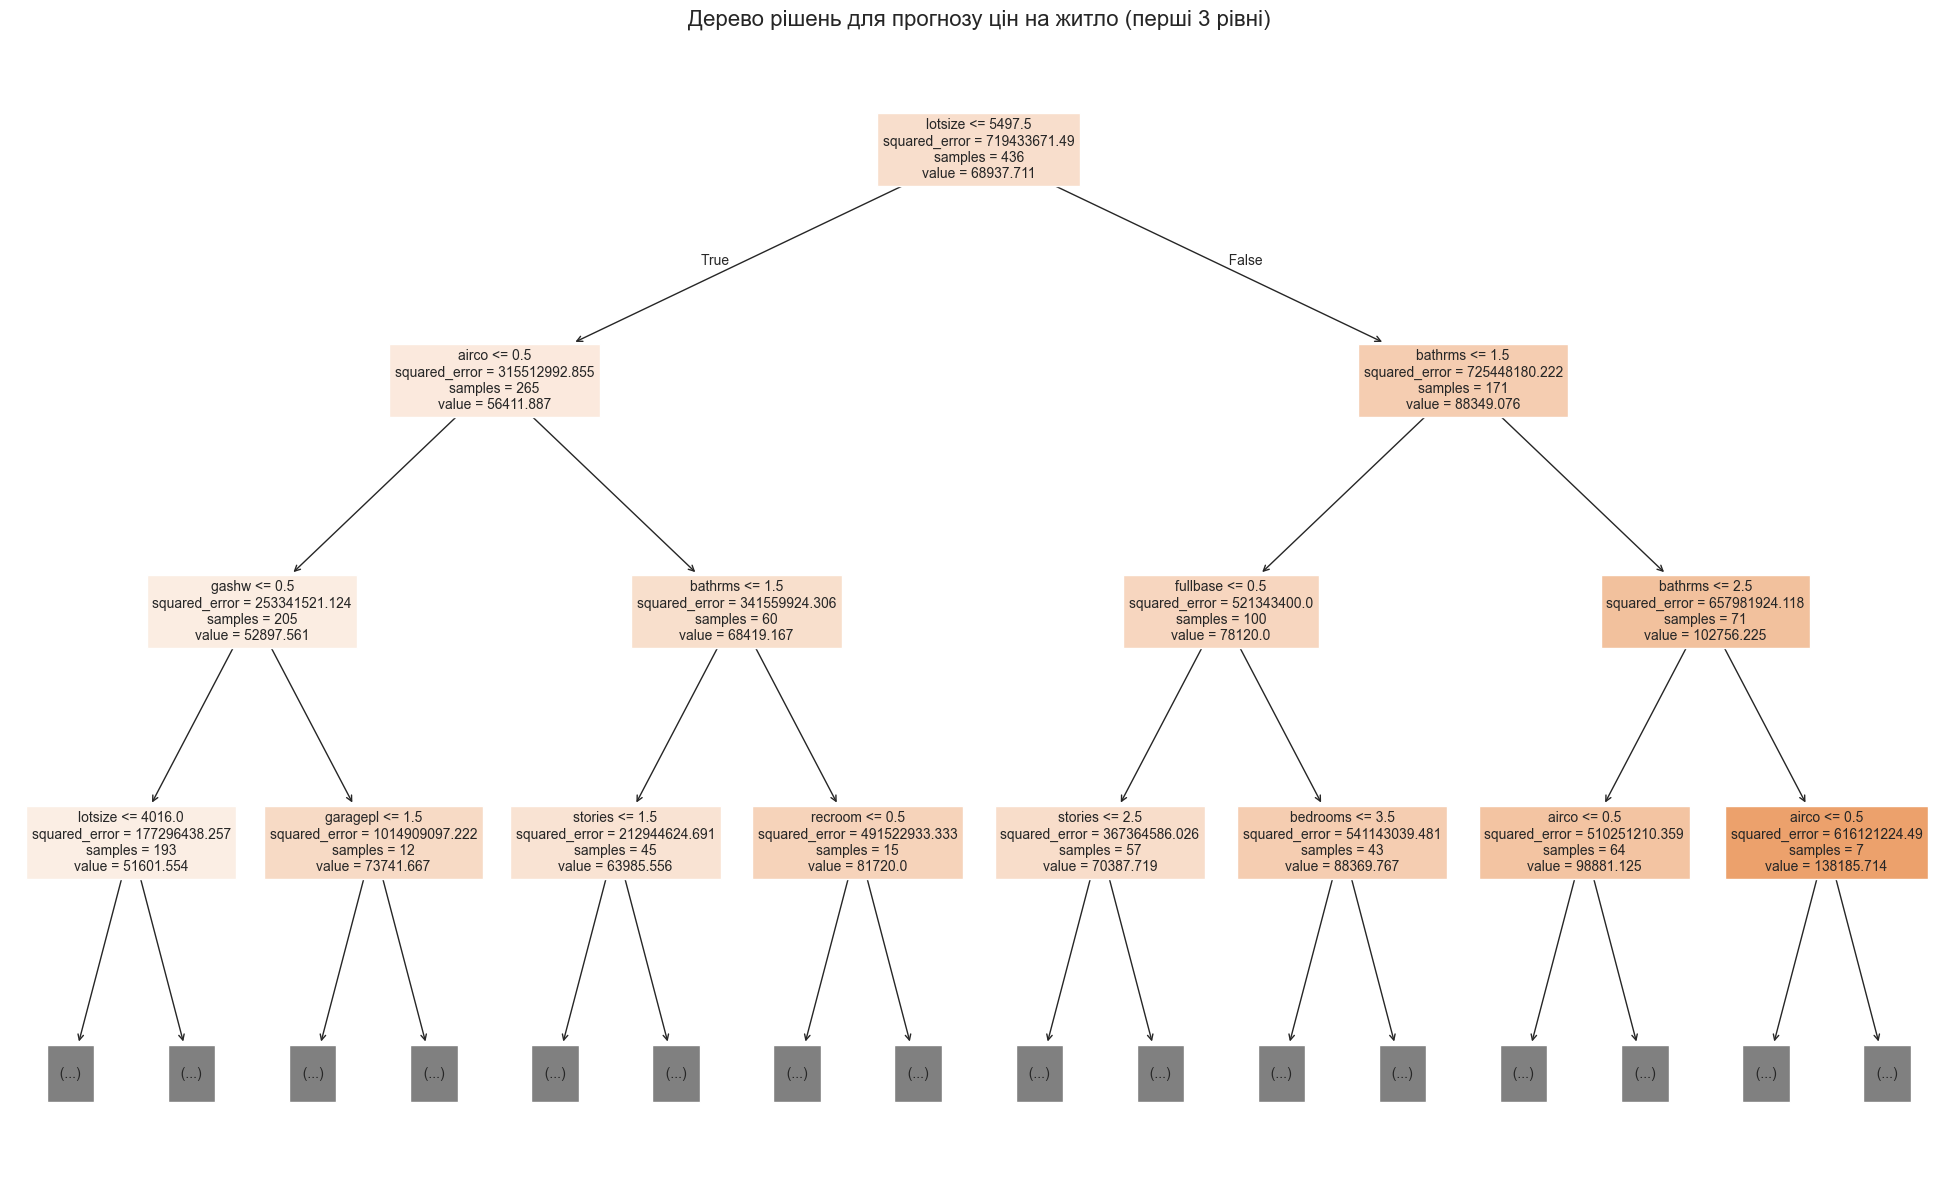

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("Завантажуємо дані з файлу housing.csv...")
try:
    df = pd.read_csv('housing.csv')
    print("Файл housing.csv успішно завантажено.")
except FileNotFoundError:
    print("Помилка: Файл 'housing.csv' не знайдено. Переконайтеся, що файл знаходиться в тій же директорії, що й скрипт.")
    exit() 

print(f"Завантажено {df.shape[0]} записів даних з {df.shape[1]} колонками.")
print("-" * 55, "\n")


print("Перші 5 рядків даних:")
print(df.head())


print("-" * 55, "\n")
# Видаляємо стовпець 'rownames', бо він не є ознакою для моделі
if 'rownames' in df.columns:
    df = df.drop('rownames', axis=1)
    print("Стовпець 'rownames' видалено.")
print("-" * 55, "\n")


print("\nПеревірка на пропущені значення:")
print(df.isnull().sum())
print("-" * 55, "\n")
df.fillna(df.mean(numeric_only=True), inplace=True)
categorical_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if x == 'yes' else 0)
        print(f"Ознака '{col}' перетворена на числову (yes=1, no=0).")


print("-" * 55, "\n")
print("\nДані після попередньої обробки (перші 5 рядків):")
print(df.head())
print("-" * 55, "\n")


X = df.drop('price', axis=1) # Ознаки
y = df['price'] # Те, що будемо передбачити
print("\nРозділяємо дані на навчальні та тестові...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Навчальна вибірка: {X_train.shape[0]} записів")
print(f"Тестова вибірка: {X_test.shape[0]} записів")


print("-" * 55, "\n")
print("\nБудуємо дерево рішень...")
model = DecisionTreeRegressor(random_state=42, max_depth=7) 
model.fit(X_train, y_train)  # Навчаємо модель
print("Дерево рішень навчено!")
print("-" * 55, "\n")


print(f"\nГлибина дерева: {model.get_depth()}")
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)
print("\nВажливість ознак:")
print(feature_importances)
print("-" * 55, "\n")


# Візуалізуємо 
plt.figure(figsize=(12, 5))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Важливість ознак для прогнозу цін на житло (Decision Tree)')
plt.xlabel('Важливість')
plt.ylabel('Ознака')
plt.show()

print("\nОцінюємо якість моделі на тестовій вибірці...")
y_pred = model.predict(X_test)

# Оцінюємо якість за допомогою RMSE та R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE на тестовій вибірці: {rmse:.2f} (Чим менше, тим краще)")
print(f"R² на тестовій вибірці: {r2:.2f} (Чим ближче до 1, тим краще)")
print("-" * 55, "\n")

print("\nВізуалізація дерева рішень (перші 3 рівні для читабельності):")
plt.figure(figsize=(25, 15)) 
plot_tree(model, filled=True, feature_names=X.columns, max_depth=3, fontsize=10)
plt.title("Дерево рішень для прогнозу цін на житло (перші 3 рівні)", fontsize=16)
plt.show()

# Задача 2. Випадковий ліс для регресії Housing Prices
- Мета: Реалізувати випадковий ліс і порівняти з деревом рішень.
- Завдання:
1.	Візьміть той самий набір даних з попередньої задачі.
2.	Побудуйте модель RandomForestRegressor.
3.	Підберіть параметри: кількість дерев, глибина.
4.	Оцініть якість на тестовій вибірці (RMSE, R²).
5.	Порівняйте з попередньою моделлю дерева.

------------------------------------------------------- 

--- Підготовка даних завершена ---
Кількість записів у тренувальному наборі: 436
Кількість записів у тестовому наборі: 110
------------------------------------------------------- 

--- 1. Модель: Дерево Рішень (Decision Tree) ---
RMSE (середня помилка): $24822.28
R-квадрат (якість пояснення): 7.77%
------------------------------------------------------- 

--- 2. Модель: Випадковий Ліс (Random Forest) ---
RMSE (середня помилка): $17598.83
R-квадрат (якість пояснення): 53.64%
------------------------------------------------------- 

--- Загальне порівняння результатів ---
Точність Випадкового Лісу (R²) вища за Дерево Рішень на 45.87%.
Середня помилка Випадкового Лісу (RMSE) менша на $7223.45.

Висновок: Модель Випадкового Лісу є більш точною та надійною для цього завдання.
------------------------------------------------------- 

--- Створення графіків... ---


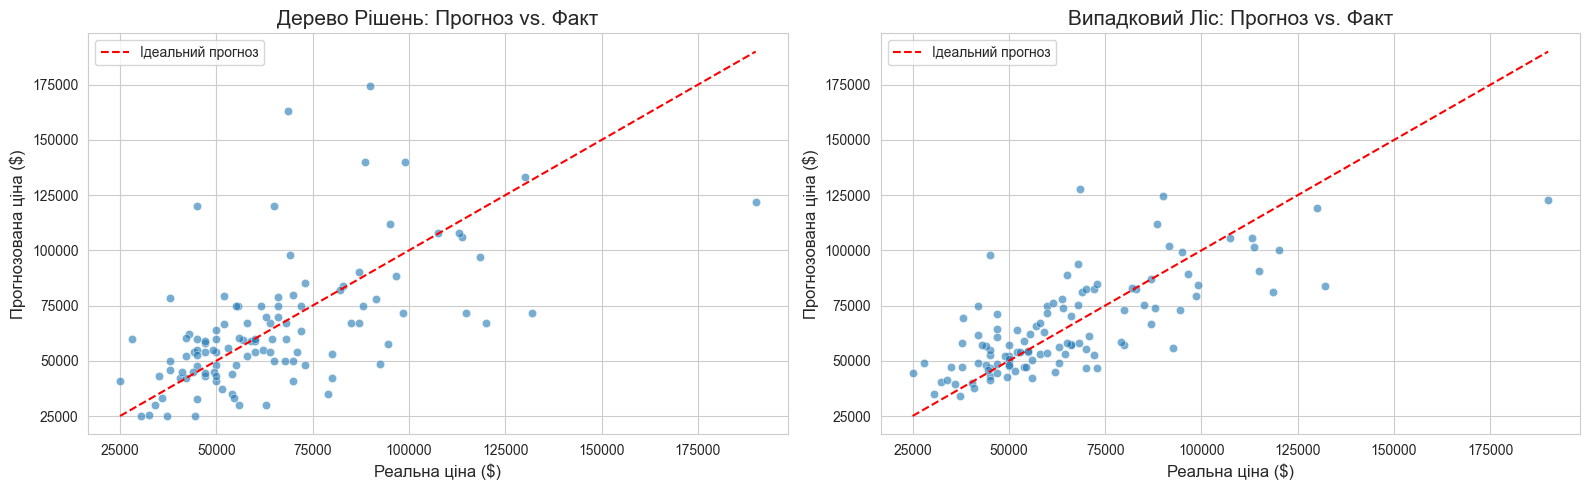

------------------------------------------------------- 



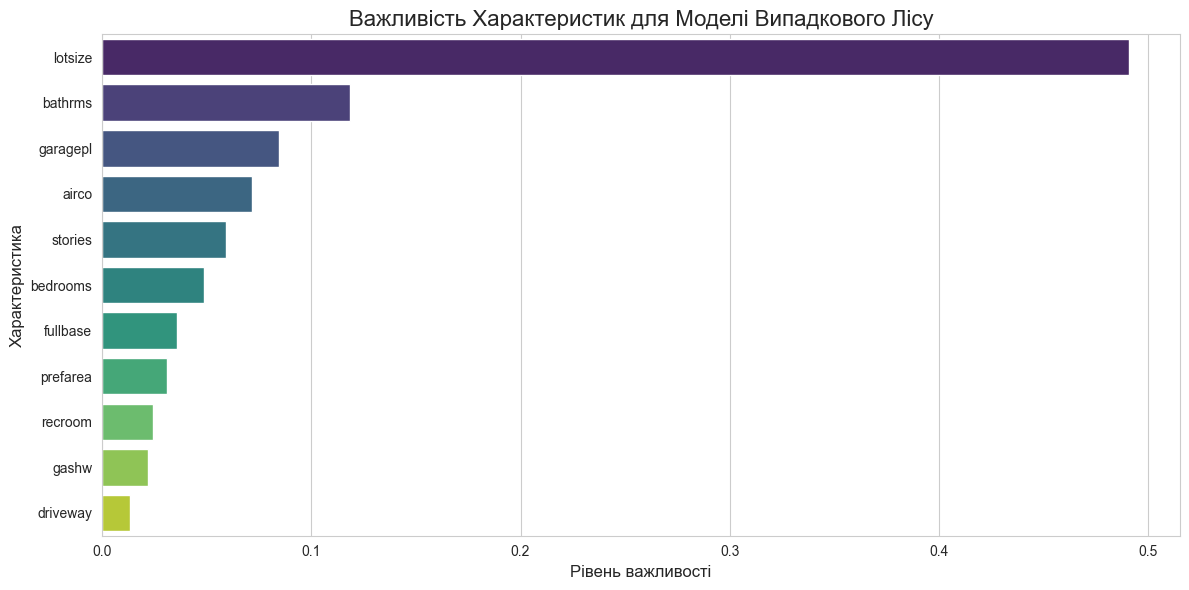

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns


# Завантажуємо дані з файлу CSV
try:
    df = pd.read_csv('Housing.csv', index_col=0)
except FileNotFoundError:
    print("Помилка: Файл 'Housing.csv' не знайдено.")
    print("Будь ласка, переконайтеся, що файл знаходиться в тій самій директорії, що і ваш скрипт.")
    exit()
print("-" * 55, "\n")


categorical_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']
for col in categorical_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


X = df.drop('price', axis=1)
y = df['price']  # Це те, що будемо шукати

# Розділяємо дані на тренувальні (80%) та тестові (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Підготовка даних завершена ---")
print(f"Кількість записів у тренувальному наборі: {len(X_train)}")
print(f"Кількість записів у тестовому наборі: {len(X_test)}")
print("-" * 55, "\n")


print("--- 1. Модель: Дерево Рішень (Decision Tree) ---")  # Навчання та оцінка моделі Дерева Рішень
tree_model = DecisionTreeRegressor(random_state=42)  # Створюємо модель.
tree_model.fit(X_train, y_train)  # Навчаємо модель на тренувальних даних
y_pred_tree = tree_model.predict(X_test)  # Робимо прогноз на тестових даних

# Оцінюємо якість моделі
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print(f"RMSE (середня помилка): ${rmse_tree:.2f}")
print(f"R-квадрат (якість пояснення): {r2_tree:.2%}")
print("-" * 55, "\n")


print("--- 2. Модель: Випадковий Ліс (Random Forest) ---")  # Навчання та оцінка моделі Випадкового Лісу
forest_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)  # Створюємо модель
forest_model.fit(X_train, y_train)  # Навчаємо модель на тих самих тренувальних даних
y_pred_forest = forest_model.predict(X_test)  # Робимо прогноз на тестових даних

# Оцінюємо якість моделі
rmse_forest = np.sqrt(mean_squared_error(y_test, y_pred_forest))
r2_forest = r2_score(y_test, y_pred_forest)

print(f"RMSE (середня помилка): ${rmse_forest:.2f}")
print(f"R-квадрат (якість пояснення): {r2_forest:.2%}")
print("-" * 55, "\n")


print("--- Загальне порівняння результатів ---")
print(f"Точність Випадкового Лісу (R²) вища за Дерево Рішень на {r2_forest - r2_tree:.2%}.")
print(f"Середня помилка Випадкового Лісу (RMSE) менша на ${rmse_tree - rmse_forest:.2f}.")
print("\nВисновок: Модель Випадкового Лісу є більш точною та надійною для цього завдання.")
print("-" * 55, "\n")


# Візуалізація "Прогноз проти Факту" 
print("--- Створення графіків... ---")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))  # Два графіки поруч 
perfect_line = np.arange(y_test.min(), y_test.max())  # Червона лінія, що показує ідеальний прогноз

# Лівий графік: Дерево Рішень
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred_tree, alpha=0.6)
axes[0].plot(perfect_line, perfect_line, color='red', linestyle='--', label='Ідеальний прогноз')
axes[0].set_title('Дерево Рішень: Прогноз vs. Факт', fontsize=15)
axes[0].set_xlabel('Реальна ціна ($)', fontsize=12)
axes[0].set_ylabel('Прогнозована ціна ($)', fontsize=12)
axes[0].legend()

# Правий графік: Випадковий Ліс
sns.scatterplot(ax=axes[1], x=y_test, y=y_pred_forest, alpha=0.6)
axes[1].plot(perfect_line, perfect_line, color='red', linestyle='--', label='Ідеальний прогноз')
axes[1].set_title('Випадковий Ліс: Прогноз vs. Факт', fontsize=15)
axes[1].set_xlabel('Реальна ціна ($)', fontsize=12)
axes[1].set_ylabel('Прогнозована ціна ($)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()
print("-" * 55, "\n")


# Візуалізація "Важливість Характеристик" для Випадкового Лісу ---
importances = forest_model.feature_importances_
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=feature_importances, hue='feature', palette='viridis', legend=False)

plt.title('Важливість Характеристик для Моделі Випадкового Лісу', fontsize=16)
plt.xlabel('Рівень важливості', fontsize=12)
plt.ylabel('Характеристика', fontsize=12)

plt.tight_layout()
plt.show()

# Задача 3. Реалізація градієнтного бустингу з XGBoost на Housing Prices
- Мета: Побудувати точну модель передбачення цін з XGBoost.
- Завдання:
1.	Підготуйте дані (housing.csv або CaliforniaHousing).
2.	Реалізуйте модель XGBRegressor.
3.	Використайте early_stopping_rounds на валідаційній вибірці.
4.	Оцініть результат: RMSE, важливість ознак, графік важливості.
5.	Порівняйте з випадковим лісом.

--- Дані підготовлено ---
Розмір тренувальної вибірки: 327
Розмір валідаційної вибірки: 109
Розмір тестової вибірки: 110
------------------------------------------------------- 

--- Початок навчання XGBoost... ---
--- Навчання XGBoost завершено! ---
------------------------------------------------------- 

RMSE для моделі XGBoost: $14379.23
------------------------------------------------------- 

--- Створення графіка важливості ознак... ---


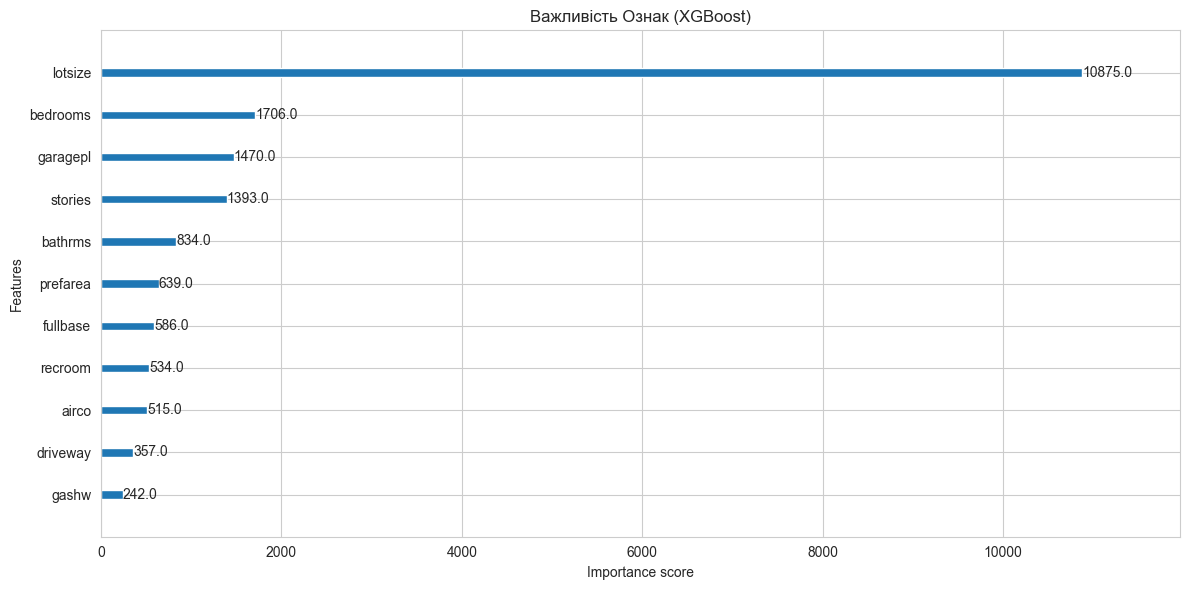


---------------------------------------------
--- ФІНАЛЬНЕ ПОРІВНЯННЯ РЕЗУЛЬТАТІВ ---
---------------------------------------------
🌲 Випадковий Ліс: RMSE = $17598.83
🚀 XGBoost:        RMSE = $14379.23
---------------------------------------------

✅ XGBoost виявився точнішим на 18.29%.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# Встановлюємо стиль для графіків
sns.set_style("whitegrid")

# Завантажуємо дані
try:
    df = pd.read_csv('Housing.csv', index_col=0)
except FileNotFoundError:
    print("Помилка: Файл 'Housing.csv' не знайдено. Переконайтесь, що він у тій самій папці.")
    exit()

categorical_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']
for col in categorical_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

X = df.drop('price', axis=1)
y = df['price']

# Розділяємо дані на тренувальну (60%), валідаційну (20%) та тестову (20%) вибірки
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

print("--- Дані підготовлено ---")
print(f"Розмір тренувальної вибірки: {len(X_train)}")
print(f"Розмір валідаційної вибірки: {len(X_val)}")
print(f"Розмір тестової вибірки: {len(X_test)}")
print("-" * 55, "\n")

# === РЕАЛІЗАЦІЯ МОДЕЛІ XGBOOST З РАННЬОЮ ЗУПИНКОЮ ===
# Створюємо модель XGBRegressor
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,         
    learning_rate=0.05,        
    max_depth=5,                # Максимальна глибина дерева
    objective='reg:squarederror', # Функція втрат для регресії
    random_state=42,
    n_jobs=-1
)

# Навчаємо модель
print("--- Початок навчання XGBoost... ---")
xgb_model.fit(X_train, y_train)
print("--- Навчання XGBoost завершено! ---")
print("-" * 55, "\n")

# === ОЦІНКА РЕЗУЛЬТАТУ XGBOOST ===
y_pred_xgb = xgb_model.predict(X_test)   # Робимо прогноз на тестовій вибірці, яку модель ще не бачила
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))  # Розраховуємо середньоквадратичну помилку (RMSE)
print(f"RMSE для моделі XGBoost: ${rmse_xgb:.2f}")
print("-" * 55, "\n")


# Візуалізація важливості ознак
print("--- Створення графіка важливості ознак... ---")
fig, ax = plt.subplots(figsize=(12, 6))
xgb.plot_importance(xgb_model, ax=ax, title='Важливість Ознак (XGBoost)')
plt.tight_layout()
plt.show()


# === ПОРІВНЯННЯ З ВИПАДКОВИМ ЛІСОМ ===
# Навчаємо модель Випадкового Лісу на тих самих даних для чесного порівняння
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_full, y_train_full) # Навчаємо на повному тренувальному наборі
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))


print("\n" + "---" * 15)
print("--- ФІНАЛЬНЕ ПОРІВНЯННЯ РЕЗУЛЬТАТІВ ---")
print("---" * 15)
print(f"🌲 Випадковий Ліс: RMSE = ${rmse_rf:.2f}")
print(f"🚀 XGBoost:        RMSE = ${rmse_xgb:.2f}")
print("-" * 45)

if rmse_xgb < rmse_rf:
    improvement = ((rmse_rf - rmse_xgb) / rmse_rf) * 100
    print(f"\n✅ XGBoost виявився точнішим на {improvement:.2f}%.")
else:
    print("\n✅ У цьому випадку Випадковий Ліс показав кращий результат.")

# Задача 4. Власноручна реалізація дерева рішень з обчисленням ентропії
- Мета: Побудувати просте дерево рішень вручну для класифікації.
- Завдання:
1.	Створіть невеликий набір даних вручну (напр., 10 рядків про покупців товару).
2.	Реалізуйте обчислення ентропії та інформаційного приросту.
3.	Побудуйте дерево до 2-3 рівнів глибини.
4.	Побудуйте схему дерева (наприклад, з використанням графіка).
5.	Поясніть кожен поділ і обчислення.

Наш набір даних:
   Вік  Є Діти  Купив
0   25       0      0
1   30       1      1
2   35       0      0
3   40       1      1
4   45       0      0
5   28       1      1
6   33       0      0
7   38       1      1
8   42       0      0
9   47       1      1
---------------------------------------------

Початкова ентропія нашого набору даних: 1.000
---------------------------------------------
Інформаційний приріст для 'Вік': 1.000
Інформаційний приріст для 'Є Діти': 1.000
---------------------------------------------

--- Перший рівень дерева: Розділення за 'Є Діти' ---
Покупці без дітей:
   Вік  Є Діти  Купив
0   25       0      0
2   35       0      0
4   45       0      0
6   33       0      0
8   42       0      0
Ентропія для 'без дітей': 0.000

Покупці з дітьми:
   Вік  Є Діти  Купив
1   30       1      1
3   40       1      1
5   28       1      1
7   38       1      1
9   47       1      1
Ентропія для 'з дітьми': 0.000
---------------------------------------------


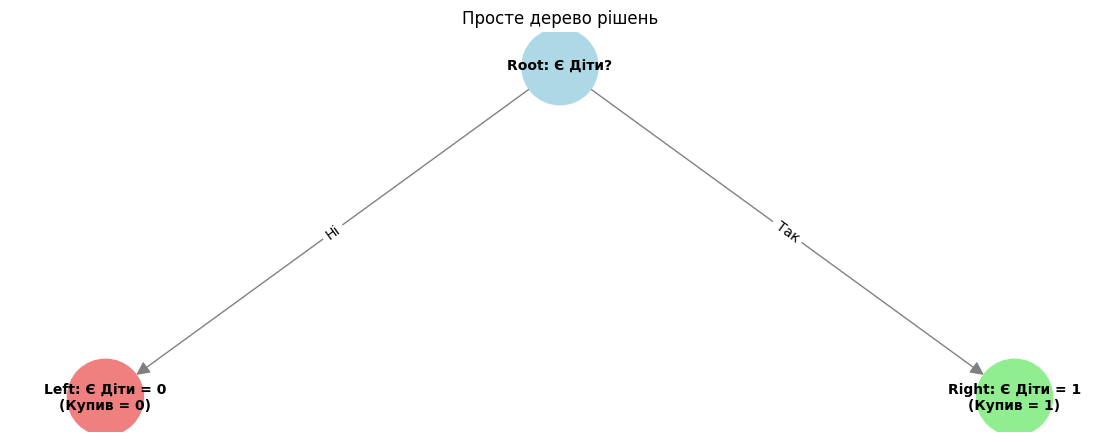

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

data = {
    'Вік': [25, 30, 35, 40, 45, 28, 33, 38, 42, 47],
    'Є Діти': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1], # Дорослі мають та не мають дітей, 0 - немає, 1 - є
    'Купив': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]  # 0 - ні, 1 - так
}
df = pd.DataFrame(data)
print("Наш набір даних:")
print(df)
print("-" * 45)


def calculate_entropy(df):    
    counts = df['Купив'].value_counts()  # Рахуємо кількість кожного значення у стовпці 'Купив'    
    total = len(df)  # Загальна кількість записів
    
    entropy = 0
    for count in counts:
        p = count / total
        entropy -= p * np.log2(p) if p > 0 else 0 
    return entropy

initial_entropy = calculate_entropy(df)
print(f"\nПочаткова ентропія нашого набору даних: {initial_entropy:.3f}")
print("-" * 45)


def calculate_information_gain(df, attribute_name, target_name='Купив'):
    total_entropy = calculate_entropy(df)      # Ентропія всього набору
    weighted_entropy = 0
    for value in df[attribute_name].unique():
        
        subset = df[df[attribute_name] == value]  # Створюємо підмножину даних        
        weight = len(subset) / len(df)  # Вага підмножини        
        entropy_subset = calculate_entropy(subset)  # Ентропія підмножини
        weighted_entropy += weight * entropy_subset
            
    information_gain = total_entropy - weighted_entropy  # Інформаційний приріст
    return information_gain

# Рахуємо інформаційний приріст для "Вік" і "Є Діти"
ig_age = calculate_information_gain(df, 'Вік')
ig_has_children = calculate_information_gain(df, 'Є Діти')

print(f"Інформаційний приріст для 'Вік': {ig_age:.3f}")
print(f"Інформаційний приріст для 'Є Діти': {ig_has_children:.3f}")
print("-" * 45)


# Перше розбиття: за 'Є Діти'
df_no_children = df[df['Є Діти'] == 0]
df_has_children = df[df['Є Діти'] == 1]

print("\n--- Перший рівень дерева: Розділення за 'Є Діти' ---")
print("Покупці без дітей:")
print(df_no_children)
print(f"Ентропія для 'без дітей': {calculate_entropy(df_no_children):.3f}")

print("\nПокупці з дітьми:")
print(df_has_children)
print(f"Ентропія для 'з дітьми': {calculate_entropy(df_has_children):.3f}")
print("-" * 45)


# Створення графа для візуалізації
G = nx.DiGraph()

G.add_node("Root: Є Діти?", shape="box", style="filled", fillcolor="lightblue")
G.add_node("Left: Є Діти = 0\n(Купив = 0)", shape="box", style="filled", fillcolor="lightcoral")
G.add_node("Right: Є Діти = 1\n(Купив = 1)", shape="box", style="filled", fillcolor="lightgreen")

G.add_edge("Root: Є Діти?", "Left: Є Діти = 0\n(Купив = 0)", label="Ні")
G.add_edge("Root: Є Діти?", "Right: Є Діти = 1\n(Купив = 1)", label="Так")

pos = {
    "Root: Є Діти?": (0, 1),
    "Left: Є Діти = 0\n(Купив = 0)": (-1, 0),
    "Right: Є Діти = 1\n(Купив = 1)": (1, 0)
}

plt.figure(figsize=(11, 4))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color=['lightblue', 'lightcoral', 'lightgreen'], 
        font_size=10, font_weight='bold', arrowsize=20, edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=10)
plt.title("Просте дерево рішень")
plt.axis('off')
plt.show()

# Задача 5. Класифікація купівлі автомобіля за допомогою логістичної регресії
- Мета: Передбачити ймовірність купівлі автомобіля на основі демографічних ознак.
- Завдання:
1.	Створіть штучний набір даних (вік, дохід, власність, стать).
2.	Реалізуйте логістичну регресію (LogisticRegression).
3.	Виведіть ваги ознак та побудуйте сигмоїдну криву.
4.	Побудуйте confusion matrix, порахуйте precision, recall, F1.
5.	Візуалізуйте роздільну гіперплощину.

Перші 5 рядків нашого набору даних:
   Вік   Дохід  Власність  Стать  Купив Автомобіль
0   58   64766          1      0                 1
1   48  103530          1      1                 1
2   34   91087          1      1                 1
3   62   98840          0      0                 1
4   27   84384          1      1                 0

Кількість людей, які купили авто: 145 з 200
---------------------------------------------------------------------------

Модель логістичної регресії навчена!
---------------------------------------------------------------------------

Ваги ознак (коефіцієнти) моделі:
Вік: 2.0256
Дохід: 0.6460
Власність: 0.3516
Стать: -0.0223
Intercept (зміщення): 1.8516
---------------------------------------------------------------------------


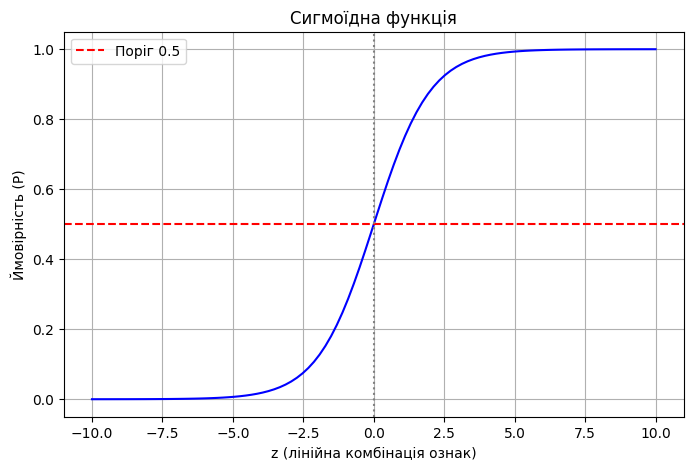

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42) 
n_samples = 200

age = np.random.randint(20, 70, n_samples)  # Вік
income = np.random.randint(30_000, 120_000, n_samples)  # Дохід
property_owner = np.random.binomial(1, 0.6, n_samples)  # Зробимо так, що люди з власністю частіше купують авто
gender = np.random.binomial(1, 0.5, n_samples)  # Стать (0: жінка, 1: чоловік)

# Створимо залежність: старші, багатші, власники майна та чоловіки частіше купують авто
buy_car_prob = (0.05 * age + 0.00001 * income + 0.3 * property_owner + 0.1 * gender + np.random.normal(0, 0.5, n_samples))
buy_car = (buy_car_prob > np.mean(buy_car_prob) - 0.5).astype(int)

# Створюємо DataFrame
data = pd.DataFrame({
    'Вік': age,
    'Дохід': income,
    'Власність': property_owner,
    'Стать': gender,
    'Купив Автомобіль': buy_car
})

print("Перші 5 рядків нашого набору даних:")
print(data.head())
print(f"\nКількість людей, які купили авто: {data['Купив Автомобіль'].sum()} з {len(data)}")
print("-" * 75)


X = data[['Вік', 'Дохід', 'Власність', 'Стать']]  # Ознаки
y = data['Купив Автомобіль']

# Розділяємо дані на тренувальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабування ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Навчаємо модель логістичної регресії
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("\nМодель логістичної регресії навчена!")
print("-" * 75)


# Виводимо ваги ознак (коефіцієнти)
print("\nВаги ознак (коефіцієнти) моделі:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept (зміщення): {model.intercept_[0]:.4f}")
print("-" * 75)


# Створимо демонстрацію
z = np.linspace(-10, 10, 100)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), color='blue')
plt.title('Сигмоїдна функція')
plt.xlabel('z (лінійна комбінація ознак)')
plt.ylabel('Ймовірність (P)')
plt.grid(True)
plt.axhline(0.5, color='red', linestyle='--', label='Поріг 0.5')
plt.axvline(0, color='gray', linestyle=':')
plt.legend()
plt.show()